In [1]:
from pathlib import Path
from IPython.display import display_markdown

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, kruskal
from scikit_posthocs import posthoc_dunn

In [2]:
results_paths = [
    Path('../../results/quantum_entropy'),
    Path('../../results/kaoetal'),
    Path('../../results/local_global_surprise')
]
corpora = [
    'humicroedit',
    'expunations',
    'HAHA@IberLEF2021'
]
corpora_paths = {
    'humicroedit': Path('../../data/humor_recognition/humicroedit.json'),
    'expunations': Path('../../data/humor_recognition/expunations.json'),
    'HAHA@IberLEF2021': Path('../../data/humor_recognition/HAHA@IberLEF2021.json')
}
metrics = [
    'QE-U + GloVe',
    'QE-I + GloVe',
    'QE-U + HF',
    'QE-I + HF',
    'local global surprise',
    'ambiguity',
    'distinctiveness'
]

In [3]:
dfs = []
for results_path in results_paths:
    for corpus in corpora:
        readpath = results_path / (corpus + '.jsonl')
        if readpath.exists():
            df = (pl.read_ndjson(readpath)
                    .with_columns(pl.lit(corpus).alias('corpus'))
                    .drop(['label', 'location', 'interpretation', 'char_count'], strict=False))
            dfs.append(df)

combined_df = pl.concat(dfs, how='diagonal_relaxed')
df = (combined_df.group_by(['index', 'text', 'corpus'])
                 .agg([pl.col(m).drop_nulls().first() for m in metrics if m in combined_df.columns]))

datasets_enum = pl.Enum(corpora)
df = (df.with_columns(pl.lit('Humor').alias('label'))
     .sort(pl.col('corpus').cast(datasets_enum)))
df

index,text,corpus,QE-U + GloVe,QE-I + GloVe,QE-U + HF,QE-I + HF,label
str,str,str,f64,f64,f64,f64,str
"""humicroedit.14560.H""","""Kushner , CIM to Get $ 600 Mil…","""humicroedit""",5.009583,-4.924549,0.530799,-0.331679,"""Humor"""
"""humicroedit.2973.H""","""Who is Rachel Crooks ? Trump s…","""humicroedit""",5.15449,-5.088636,0.519454,-0.32435,"""Humor"""
"""humicroedit.8157.H""","""Defense Dept. charged nearly $…","""humicroedit""",5.005617,-4.932447,1.703141,-1.340264,"""Humor"""
"""humicroedit.4469.H""","""Trump , GOP tax plan omits det…","""humicroedit""",4.990154,-4.908397,0.657176,-0.451719,"""Humor"""
"""humicroedit.10070.N""","""Lawmaker Who Assaulted Reporte…","""humicroedit""",5.351624,-5.296287,0.581507,-0.418964,"""Humor"""
…,…,…,…,…,…,…,…
"""HAHA@IberLEF2021.tweet28693""","""a qué edad se aprende a hablar…","""HAHA@IberLEF2021""",5.333019,-5.273075,0.606231,-0.429028,"""Humor"""
"""HAHA@IberLEF2021.tweet13696""","""No les parcece raro esas perso…","""HAHA@IberLEF2021""",5.192304,null,0.598246,-0.403679,"""Humor"""
"""HAHA@IberLEF2021.tweet5321""","""Si el Dr. Simi le dedicara más…","""HAHA@IberLEF2021""",5.231384,-5.154054,0.654928,-0.339552,"""Humor"""


In [4]:
corpora_dfs = []
for corpus in corpora:
    corpus_df = pd.read_json(corpora_paths[corpus], orient='index')
    corpus_df = corpus_df.rename_axis('index').reset_index()
    corpus_df = corpus_df[['index', 'funniness']]
    corpora_dfs.append(pl.from_dataframe(corpus_df))

funniness_df = pl.concat(corpora_dfs)
df = df.join(funniness_df, on='index', how='left')
df

index,text,corpus,QE-U + GloVe,QE-I + GloVe,QE-U + HF,QE-I + HF,label,funniness
str,str,str,f64,f64,f64,f64,str,f64
"""humicroedit.14560.H""","""Kushner , CIM to Get $ 600 Mil…","""humicroedit""",5.009583,-4.924549,0.530799,-0.331679,"""Humor""",0.2
"""humicroedit.2973.H""","""Who is Rachel Crooks ? Trump s…","""humicroedit""",5.15449,-5.088636,0.519454,-0.32435,"""Humor""",0.2
"""humicroedit.8157.H""","""Defense Dept. charged nearly $…","""humicroedit""",5.005617,-4.932447,1.703141,-1.340264,"""Humor""",0.6
"""humicroedit.4469.H""","""Trump , GOP tax plan omits det…","""humicroedit""",4.990154,-4.908397,0.657176,-0.451719,"""Humor""",0.2
"""humicroedit.10070.N""","""Lawmaker Who Assaulted Reporte…","""humicroedit""",5.351624,-5.296287,0.581507,-0.418964,"""Humor""",null
…,…,…,…,…,…,…,…,…
"""HAHA@IberLEF2021.tweet28693""","""a qué edad se aprende a hablar…","""HAHA@IberLEF2021""",5.333019,-5.273075,0.606231,-0.429028,"""Humor""",null
"""HAHA@IberLEF2021.tweet13696""","""No les parcece raro esas perso…","""HAHA@IberLEF2021""",5.192304,null,0.598246,-0.403679,"""Humor""",null
"""HAHA@IberLEF2021.tweet5321""","""Si el Dr. Simi le dedicara más…","""HAHA@IberLEF2021""",5.231384,-5.154054,0.654928,-0.339552,"""Humor""",null


In [5]:
df = df.filter(~pl.col('funniness').is_null())
df.group_by('corpus').len()

corpus,len
str,u64
"""expunations""",445
"""HAHA@IberLEF2021""",3001
"""humicroedit""",3211


### Quantile analysis

In [6]:
melted_df = df.unpivot(on=None, variable_name='metric',
                       index=['index', 'text', 'corpus', 'label', 'funniness'])
melted_df

index,text,corpus,label,funniness,metric,value
str,str,str,str,f64,str,f64
"""humicroedit.14560.H""","""Kushner , CIM to Get $ 600 Mil…","""humicroedit""","""Humor""",0.2,"""QE-U + GloVe""",5.009583
"""humicroedit.2973.H""","""Who is Rachel Crooks ? Trump s…","""humicroedit""","""Humor""",0.2,"""QE-U + GloVe""",5.15449
"""humicroedit.8157.H""","""Defense Dept. charged nearly $…","""humicroedit""","""Humor""",0.6,"""QE-U + GloVe""",5.005617
"""humicroedit.4469.H""","""Trump , GOP tax plan omits det…","""humicroedit""","""Humor""",0.2,"""QE-U + GloVe""",4.990154
"""humicroedit.7186.H""","""x Wrestling ’s new villain cal…","""humicroedit""","""Humor""",1.2,"""QE-U + GloVe""",5.342215
…,…,…,…,…,…,…
"""HAHA@IberLEF2021.tweet4018""","""Típico: Entre mas tareas tiene…","""HAHA@IberLEF2021""","""Humor""",1.285714,"""QE-I + HF""",-0.47076
"""HAHA@IberLEF2021.tweet15389""","""Mi cama y yo nos amamos, pero …","""HAHA@IberLEF2021""","""Humor""",2.0,"""QE-I + HF""",-0.295131
"""HAHA@IberLEF2021.tweet3298""","""Existen dos tipos de personas …","""HAHA@IberLEF2021""","""Humor""",1.5,"""QE-I + HF""",-0.373096


In [7]:
quantiles = (melted_df.group_by(['corpus', 'metric'])
                      .agg(pl.col('value').quantile(0.25).alias('Q1'),
                           pl.col('value').quantile(0.5).alias('Q2'),
                           pl.col('value').quantile(0.75).alias('Q3'))
                      .with_columns((pl.col('Q3') - pl.col('Q1')).alias('IQR'))
                      .with_columns((pl.col('Q1') - 1.5 * pl.col('IQR')).alias('F1'),
                                    (pl.col('Q3') + 1.5 * pl.col('IQR')).alias('F2')))

with pl.Config(tbl_rows=12):
    display(quantiles.sort(pl.col('corpus').cast(datasets_enum)))

corpus,metric,Q1,Q2,Q3,IQR,F1,F2
str,str,f64,f64,f64,f64,f64,f64
"""humicroedit""","""QE-U + HF""",0.528869,0.559969,0.595487,0.066619,0.428941,0.695415
"""humicroedit""","""QE-I + HF""",-0.396873,-0.366344,-0.335613,0.061259,-0.488762,-0.243724
"""humicroedit""","""QE-U + GloVe""",5.05372,5.173874,5.264197,0.210478,4.738003,5.579914
"""humicroedit""","""QE-I + GloVe""",-5.183389,-5.077046,-4.94812,0.235269,-5.536293,-4.595217
"""expunations""","""QE-U + HF""",0.534335,0.560551,0.591667,0.057331,0.448339,0.677663
"""expunations""","""QE-I + HF""",-0.361454,-0.326744,-0.290875,0.070579,-0.467323,-0.185006
"""expunations""","""QE-I + GloVe""",-4.944371,-4.87032,-4.788182,0.156189,-5.178654,-4.553898
"""expunations""","""QE-U + GloVe""",4.928157,5.000472,5.07409,0.145933,4.709258,5.292989
"""HAHA@IberLEF2021""","""QE-I + HF""",-0.417628,-0.372439,-0.334291,0.083337,-0.542633,-0.209286


In [8]:
df_with_quantiles = melted_df.join(quantiles, on=['corpus', 'metric'])
is_low_outlier = (pl.col('value') < pl.col('F1'))
is_high_outlier = (pl.col('value') > pl.col('F2'))
df_no_outliers = df_with_quantiles.filter(~(is_low_outlier | is_high_outlier)).select(melted_df.columns)

df_no_outliers.group_by('corpus').len()

corpus,len
str,u64
"""HAHA@IberLEF2021""",11291
"""expunations""",1695
"""humicroedit""",12311


### Correlation analysis

In [9]:
corr_df = (
    df_no_outliers
    .drop_nulls(subset=['funniness', 'value'])
    .group_by(['corpus', 'metric'])
    .agg(
        pl.corr(pl.col('funniness'), pl.col('value')).alias('correlation')
    )
)

metrics_enum = pl.Enum(metrics)
with pl.Config(tbl_rows=12):
    display(corr_df.sort(pl.col('metric').cast(metrics_enum),
                         pl.col('corpus').cast(datasets_enum)))

corpus,metric,correlation
str,str,f64
"""humicroedit""","""QE-U + GloVe""",0.003702
"""expunations""","""QE-U + GloVe""",-0.022143
"""HAHA@IberLEF2021""","""QE-U + GloVe""",0.056272
"""humicroedit""","""QE-I + GloVe""",0.007743
"""expunations""","""QE-I + GloVe""",0.055523
"""HAHA@IberLEF2021""","""QE-I + GloVe""",-0.061034
"""humicroedit""","""QE-U + HF""",0.006446
"""expunations""","""QE-U + HF""",0.046153
"""HAHA@IberLEF2021""","""QE-U + HF""",0.025101


## Plots

### Funniness

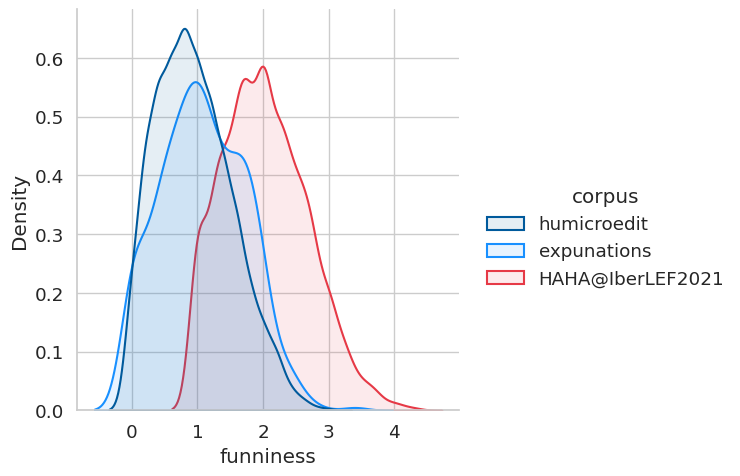

In [10]:
sns.set_theme(style="whitegrid", font_scale=1.2)

corpus_palette = {
    'humicroedit': '#005A9C',
    'expunations': '#1890FF',
    'HAHA@IberLEF2021': '#E63946',
}

sns.displot(
    df,
    x='funniness',
    hue='corpus',
    kind='kde',
    common_norm=False,
    palette=corpus_palette,
    fill=True,
    alpha=0.1,
    linewidth=1.5,
    hue_order=corpora
)

### Funniness vs. Metrics

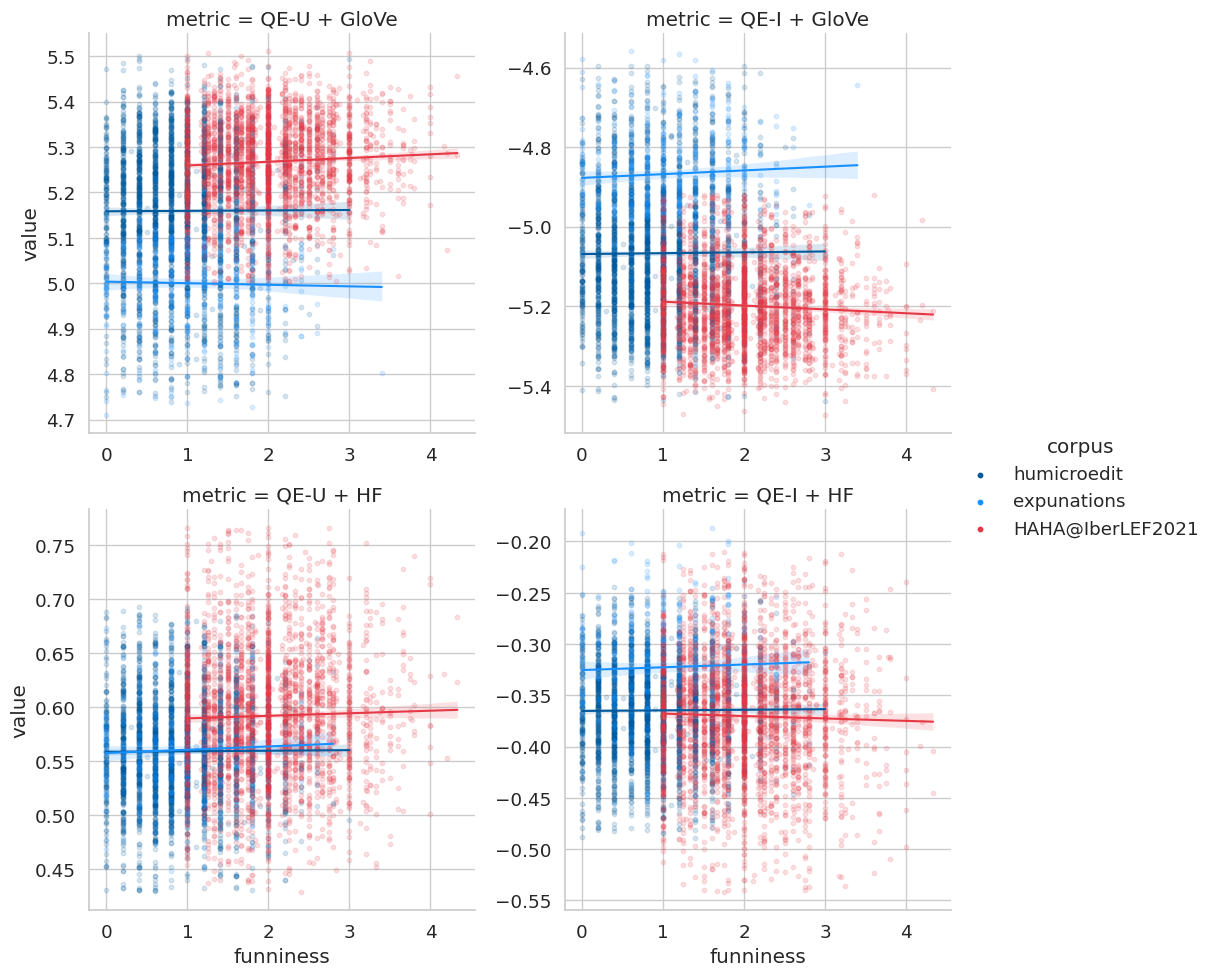

In [11]:
g = sns.lmplot(
    data=df_no_outliers, 
    x='funniness', 
    y='value', 
    hue='corpus', 
    col='metric', 
    col_wrap=2,
    palette=corpus_palette, 
    facet_kws={'sharex': False, 'sharey': False, 'legend_out': True},
    scatter_kws={'alpha': 0.15, 's': 10},
    line_kws={'linewidth': 1.5},
    hue_order=corpora
)

for handle in g.legend.legend_handles:
    handle.set_alpha(1.0)
plt.show()

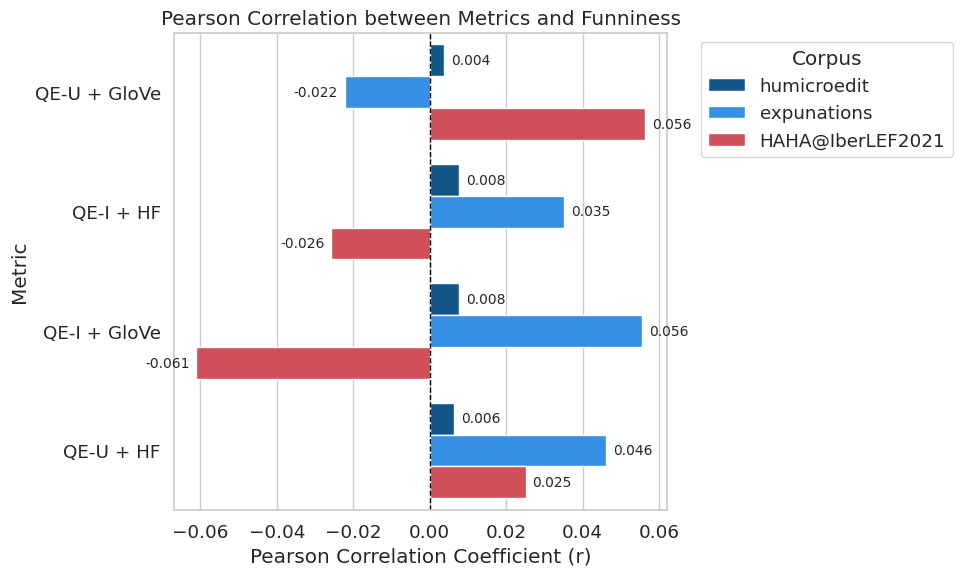

In [12]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=corr_df, 
    x='correlation', 
    y='metric', 
    hue='corpus', 
    palette=corpus_palette,
    hue_order=corpora
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt='%.3f', padding=5)

plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('Pearson Correlation between Metrics and Funniness')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.ylabel('Metric')
plt.legend(title='Corpus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Binned analysis

In [13]:
binned_df = df_no_outliers.with_columns(
    pl.col('funniness')
    .qcut(3, labels=['low', 'mid', 'high'])
    .over(['corpus', 'metric'])
    .alias('funniness bin')
)
binned_df

index,text,corpus,label,funniness,metric,value,funniness bin
str,str,str,str,f64,str,f64,cat
"""humicroedit.14560.H""","""Kushner , CIM to Get $ 600 Mil…","""humicroedit""","""Humor""",0.2,"""QE-U + GloVe""",5.009583,"""low"""
"""humicroedit.2973.H""","""Who is Rachel Crooks ? Trump s…","""humicroedit""","""Humor""",0.2,"""QE-U + GloVe""",5.15449,"""low"""
"""humicroedit.8157.H""","""Defense Dept. charged nearly $…","""humicroedit""","""Humor""",0.6,"""QE-U + GloVe""",5.005617,"""low"""
"""humicroedit.4469.H""","""Trump , GOP tax plan omits det…","""humicroedit""","""Humor""",0.2,"""QE-U + GloVe""",4.990154,"""low"""
"""humicroedit.7186.H""","""x Wrestling ’s new villain cal…","""humicroedit""","""Humor""",1.2,"""QE-U + GloVe""",5.342215,"""mid"""
…,…,…,…,…,…,…,…
"""HAHA@IberLEF2021.tweet4018""","""Típico: Entre mas tareas tiene…","""HAHA@IberLEF2021""","""Humor""",1.285714,"""QE-I + HF""",-0.47076,"""low"""
"""HAHA@IberLEF2021.tweet15389""","""Mi cama y yo nos amamos, pero …","""HAHA@IberLEF2021""","""Humor""",2.0,"""QE-I + HF""",-0.295131,"""mid"""
"""HAHA@IberLEF2021.tweet3298""","""Existen dos tipos de personas …","""HAHA@IberLEF2021""","""Humor""",1.5,"""QE-I + HF""",-0.373096,"""low"""


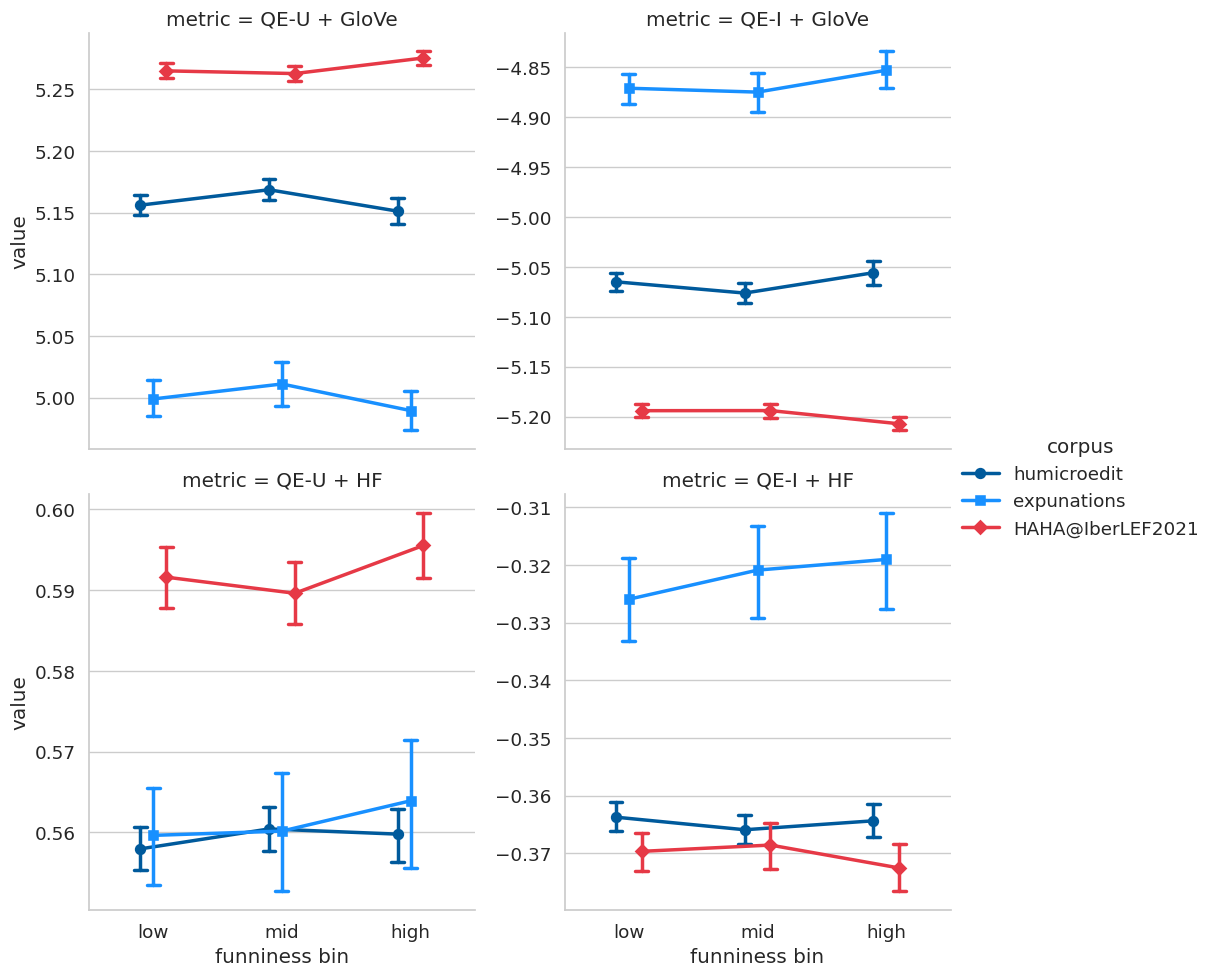

In [14]:
sns.catplot(
    data=binned_df,
    x='funniness bin',
    y='value',
    hue='corpus',
    col='metric',
    col_wrap=2,
    order=['low', 'mid', 'high'],
    sharey=False,
    palette=corpus_palette,
    kind='point',
    dodge=0.2,
    capsize=0.1,
    markers=['o', 's', 'D'],
    linewidth=2.5,
    hue_order=corpora
)

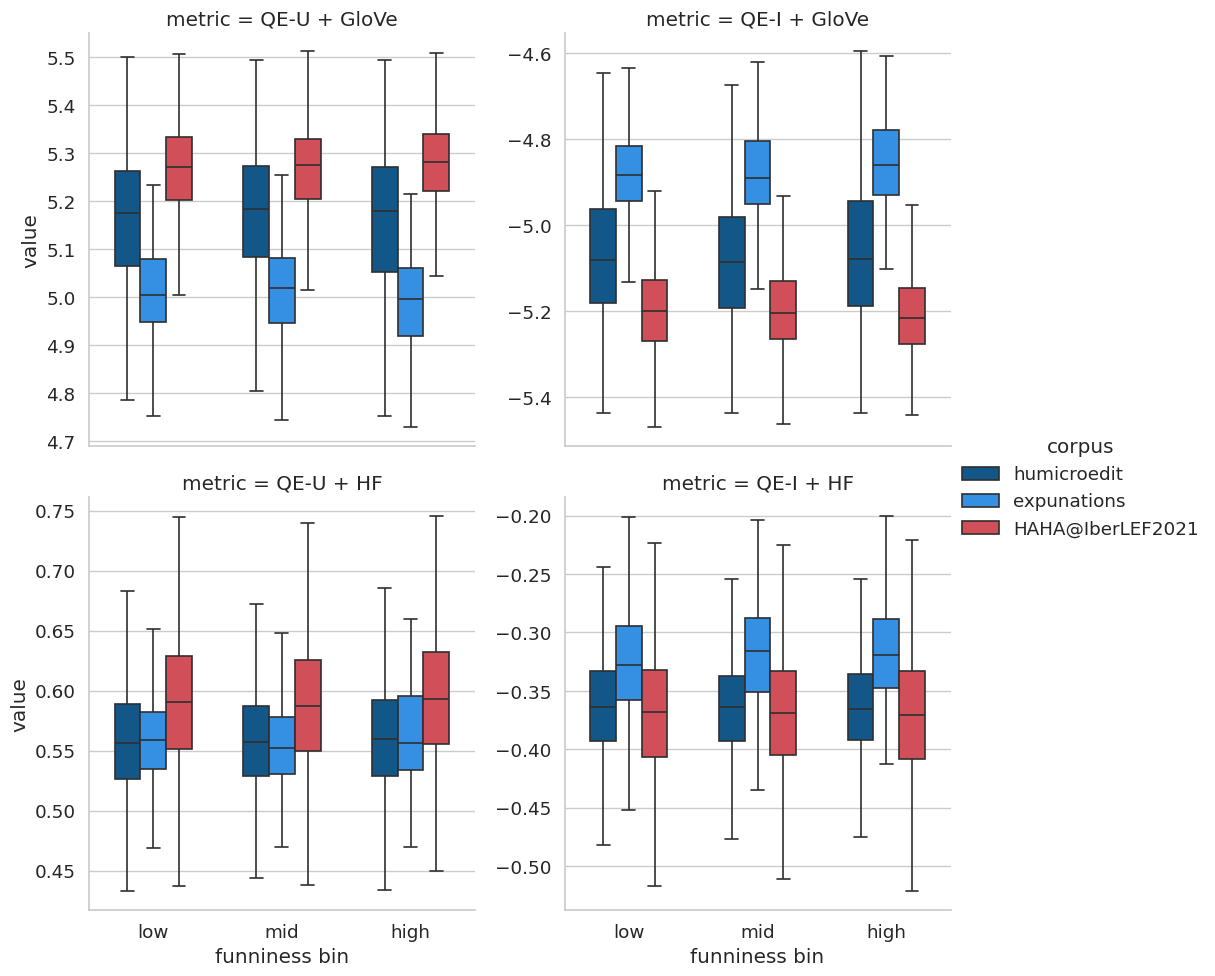

In [15]:
sns.catplot(
    data=binned_df,
    x='funniness bin',
    y='value',
    hue='corpus',
    col='metric',
    col_wrap=2,
    kind='box',
    order=['low', 'mid', 'high'],
    palette=corpus_palette,
    sharey=False,
    showfliers=False,
    width=0.6,
    linewidth=1.2
)

## Statistical tests (no outliers)

### Binned Analysis (Kruskall-Wallis H-test)

In [16]:
results = []
for metric in metrics:
    for corpus in corpora:
        binned_metric = (
            binned_df
            .filter((pl.col('metric') == metric) & (pl.col('corpus') == corpus))
            .select(['value', 'funniness bin'])
            .group_by('funniness bin')
            .all()['value']
            .to_numpy()
        )
        if binned_metric.shape == (3,):
            statistic, pvalue = kruskal(*binned_metric)

            dunn_result = posthoc_dunn(binned_metric, p_adjust='bonferroni')
            dunn_result.columns = ['low', 'mid', 'high']
            dunn_result.index = ['low', 'mid', 'high']

            results.append({
                'metric': metric,
                'corpus': corpus,
                'statistic': statistic,
                'p value': pvalue,
                'significantly different': pvalue < 0.05,
                'low vs mid dunn': dunn_result.loc['low', 'mid'],
                'low vs high dunn': dunn_result.loc['low', 'high'],
                'mid vs high dunn': dunn_result.loc['mid', 'high']
            })


results_df = (
    pl.DataFrame(results)
      .sort(
        pl.col('metric').cast(metrics_enum),
        pl.col('corpus').cast(datasets_enum)
        )
    )

with pl.Config(tbl_rows=12):
    display(results_df)

metric,corpus,statistic,p value,significantly different,low vs mid dunn,low vs high dunn,mid vs high dunn
str,str,f64,f64,i64,f64,f64,f64
"""QE-U + GloVe""","""humicroedit""",5.296945,0.070759,0,0.134787,1.0,0.160961
"""QE-U + GloVe""","""expunations""",3.508741,0.173016,0,1.0,0.699193,0.187921
"""QE-U + GloVe""","""HAHA@IberLEF2021""",8.015468,0.018175,1,1.0,0.050606,0.035431
"""QE-I + GloVe""","""humicroedit""",5.053128,0.079933,0,0.302191,1.0,0.10159
"""QE-I + GloVe""","""expunations""",4.055758,0.131614,0,0.253772,0.207621,1.0
"""QE-I + GloVe""","""HAHA@IberLEF2021""",8.484489,0.014375,1,1.0,0.030065,0.039611
"""QE-U + HF""","""humicroedit""",1.443479,0.485906,0,1.0,0.714571,1.0
"""QE-U + HF""","""expunations""",0.600851,0.740503,0,1.0,1.0,1.0
"""QE-U + HF""","""HAHA@IberLEF2021""",4.413304,0.110069,0,1.0,0.519471,0.115144
